# Preprocessing & EDA — Gym Industry Data

Comprehensive exploratory data analysis of `clean_gym_data.csv` (2000–2026, 132 countries).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('clean_gym_data.csv')
print('Loaded successfully')

Loaded successfully


## 1. Initial Data Inspection

In [2]:
print(f'Shape: {df.shape}')
print(f'Period: {df.year.min()} - {df.year.max()}')
print(f'Countries: {df.country.nunique()}')
print(f'Regions: {df.region.nunique()}')
df.head(10)

Shape: (3564, 14)
Period: 2000 - 2026
Countries: 132
Regions: 6


,country,year,region,gym_memberships,fitness_participation_rate,total_health_club_revenue_usd,number_of_gyms,gym_penetration_rate,urban_population_percentage,obesity_rate,gdp_per_capita_usd,population_total,average_membership_cost_usd,insufficient_physical_activity_pct
0,Angola,2000,Africa,95521.0,0.3873,5731259.0,204.0,0.0059,0.5051,0.0470,563.7338,16194869.0,5.00,0.2219
1,Angola,2001,Africa,103840.0,0.3939,6230372.0,222.0,0.0062,0.5172,0.0496,533.5862,16747208.0,5.00,0.2192
2,Angola,2002,Africa,121093.0,0.4003,7265583.0,249.0,0.0070,0.5289,0.0522,999.0659,17327699.0,5.00,0.2164
3,Angola,2003,Africa,142783.0,0.4065,8566966.0,281.0,0.0080,0.5400,0.0548,1133.6633,17943712.0,5.00,0.2137
4,Angola,2004,Africa,179615.0,0.4124,10776918.0,325.0,0.0097,0.5504,0.0574,1451.4712,18600423.0,5.00,0.2110
5,Angola,2005,Africa,239785.0,0.4180,14387122.0,386.0,0.0124,0.5600,0.0599,2145.8862,19291161.0,5.00,0.2083
6,Angola,2006,Africa,302516.0,0.4233,18150969.0,447.0,0.0151,0.5689,0.0625,2930.4443,20015279.0,5.00,0.2056
7,Angola,2007,Africa,357832.0,0.4285,21469922.0,504.0,0.0172,0.5776,0.0649,3515.0568,20778561.0,5.00,0.2030
8,Angola,2008,Africa,435685.0,0.4336,28336955.0,576.0,0.0202,0.5859,0.0674,4578.1553,21578655.0,5.42,0.2003
9,Angola,2009,Africa,435395.0,0.4386,26332687.0,608.0,0.0194,0.5938,0.0697,3645.1485,22414773.0,5.04,0.1975


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3564 entries, 0 to 3563
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   country                             3564 non-null   str    
 1   year                                3564 non-null   int64  
 2   region                              3564 non-null   str    
 3   gym_memberships                     3564 non-null   float64
 4   fitness_participation_rate          3564 non-null   float64
 5   total_health_club_revenue_usd       3564 non-null   float64
 6   number_of_gyms                      3564 non-null   float64
 7   gym_penetration_rate                3564 non-null   float64
 8   urban_population_percentage         3564 non-null   float64
 9   obesity_rate                        3564 non-null   float64
 10  gdp_per_capita_usd                  3564 non-null   float64
 11  population_total                    3564 non-null   fl

## 2. Missing Values & Duplicates

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_df = pd.DataFrame({'count': missing, 'percent': missing_pct})
missing_df[missing_df['count'] > 0]

,count,percent


In [5]:
# Duplicates check
dups = df.duplicated(keep='first')
print(f'Exact duplicate rows: {dups.sum()}')

# Duplicates by (country, year) — should be unique
dups_key = df.duplicated(subset=['country', 'year'], keep=False)
print(f'Duplicate (country, year) pairs: {dups_key.sum()}')

Exact duplicate rows: 0
Duplicate (country, year) pairs: 0


## 3. Statistical Summary

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,3564.0,2.013000e+03,7.789974e+00,2000.0000,2.006000e+03,2.013000e+03,2.020000e+03,2.026000e+03
gym_memberships,3564.0,2.376142e+06,7.129730e+06,2051.0000,1.628528e+05,5.108880e+05,1.560638e+06,1.027881e+08
fitness_participation_rate,3564.0,3.978917e-01,8.734487e-02,0.2047,3.331000e-01,3.999000e-01,4.537500e-01,6.758000e-01
total_health_club_revenue_usd,3564.0,6.034040e+08,2.981056e+09,164875.0000,1.533129e+07,5.568824e+07,2.737641e+08,8.486183e+10
number_of_gyms,3564.0,2.076547e+03,5.227710e+03,3.0000,2.050000e+02,5.560000e+02,1.580750e+03,6.223300e+04
gym_penetration_rate,3564.0,6.721305e-02,5.798428e-02,0.0023,1.960000e-02,5.220000e-02,9.950000e-02,3.022000e-01
urban_population_percentage,3564.0,6.100072e-01,2.190715e-01,0.1164,4.634750e-01,6.339500e-01,7.841750e-01,1.000000e+00
obesity_rate,3564.0,1.878919e-01,1.047015e-01,0.0028,1.029750e-01,1.961000e-01,2.594000e-01,6.124000e-01
gdp_per_capita_usd,3564.0,1.561527e+04,2.127239e+04,109.5938,2.011057e+03,5.830213e+03,2.145562e+04,1.377817e+05
population_total,3564.0,5.185536e+07,1.657860e+08,181685.0000,4.467102e+06,1.210349e+07,3.803110e+07,1.450936e+09


In [7]:
# Skewness for numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns
skew = df[num_cols].skew().sort_values(ascending=False)
pd.DataFrame({'skewness': skew, 'kurtosis': df[num_cols].kurtosis()})

,skewness,kurtosis
average_membership_cost_usd,2.266802,5.765693
fitness_participation_rate,0.223544,-0.296873
gdp_per_capita_usd,2.150741,5.250975
gym_memberships,7.629088,71.414296
gym_penetration_rate,1.137209,0.902066
insufficient_physical_activity_pct,0.638186,0.087186
number_of_gyms,6.566614,54.807176
obesity_rate,0.282995,0.015416
population_total,6.963572,50.918011
total_health_club_revenue_usd,16.718970,390.225062


## 4. Categorical Analysis

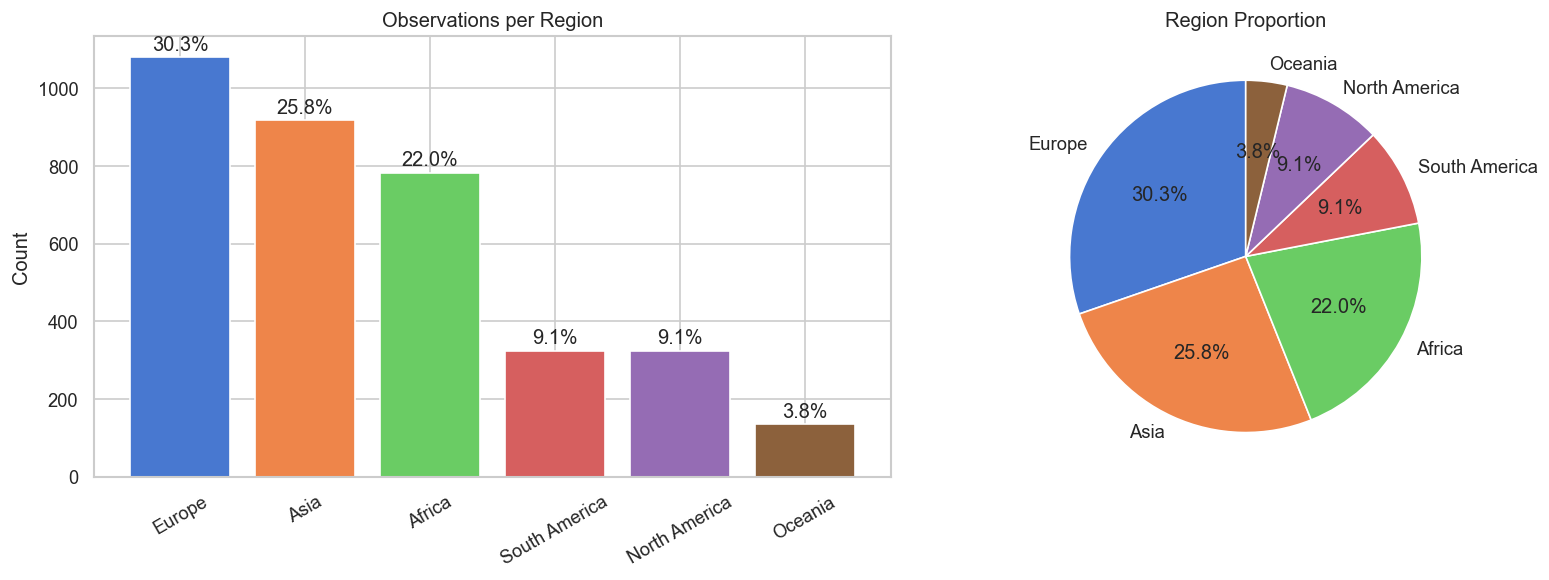

In [8]:
# Region distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_counts = df['region'].value_counts()
ax1 = axes[0]
bars = ax1.bar(region_counts.index, region_counts.values, color=sns.color_palette('muted', 6))
ax1.bar_label(bars, labels=[f'{v/len(df)*100:.1f}%' for v in region_counts.values], padding=2)
ax1.set_title('Observations per Region')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=30)

ax2 = axes[1]
ax2.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('muted', 6), startangle=90)
ax2.set_title('Region Proportion')

plt.tight_layout()
plt.show()

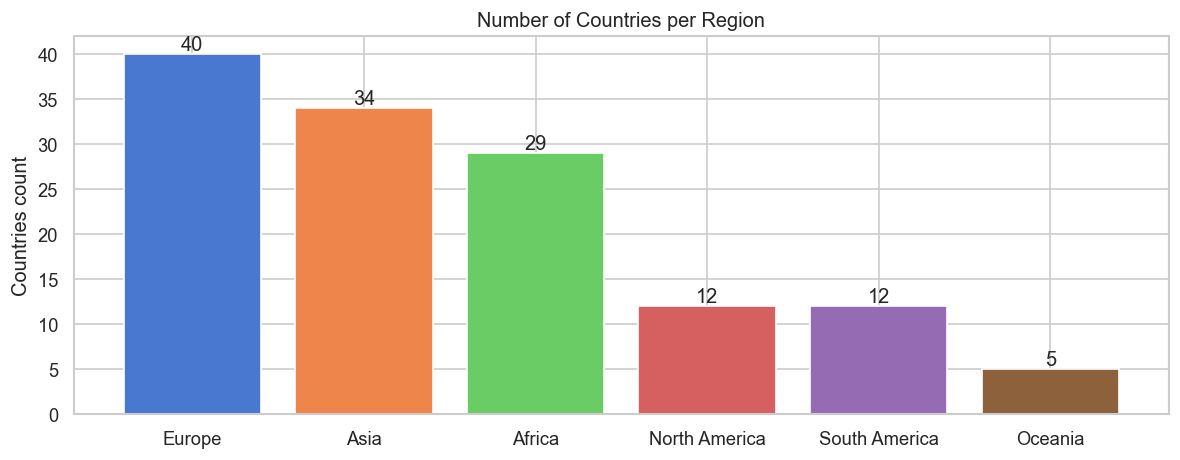

In [9]:
# Countries per region
cpr = df.groupby('region')['country'].nunique().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
bars = plt.bar(cpr.index, cpr.values, color=sns.color_palette('muted', 6))
plt.bar_label(bars)
plt.title('Number of Countries per Region')
plt.ylabel('Countries count')
plt.tight_layout()
plt.show()

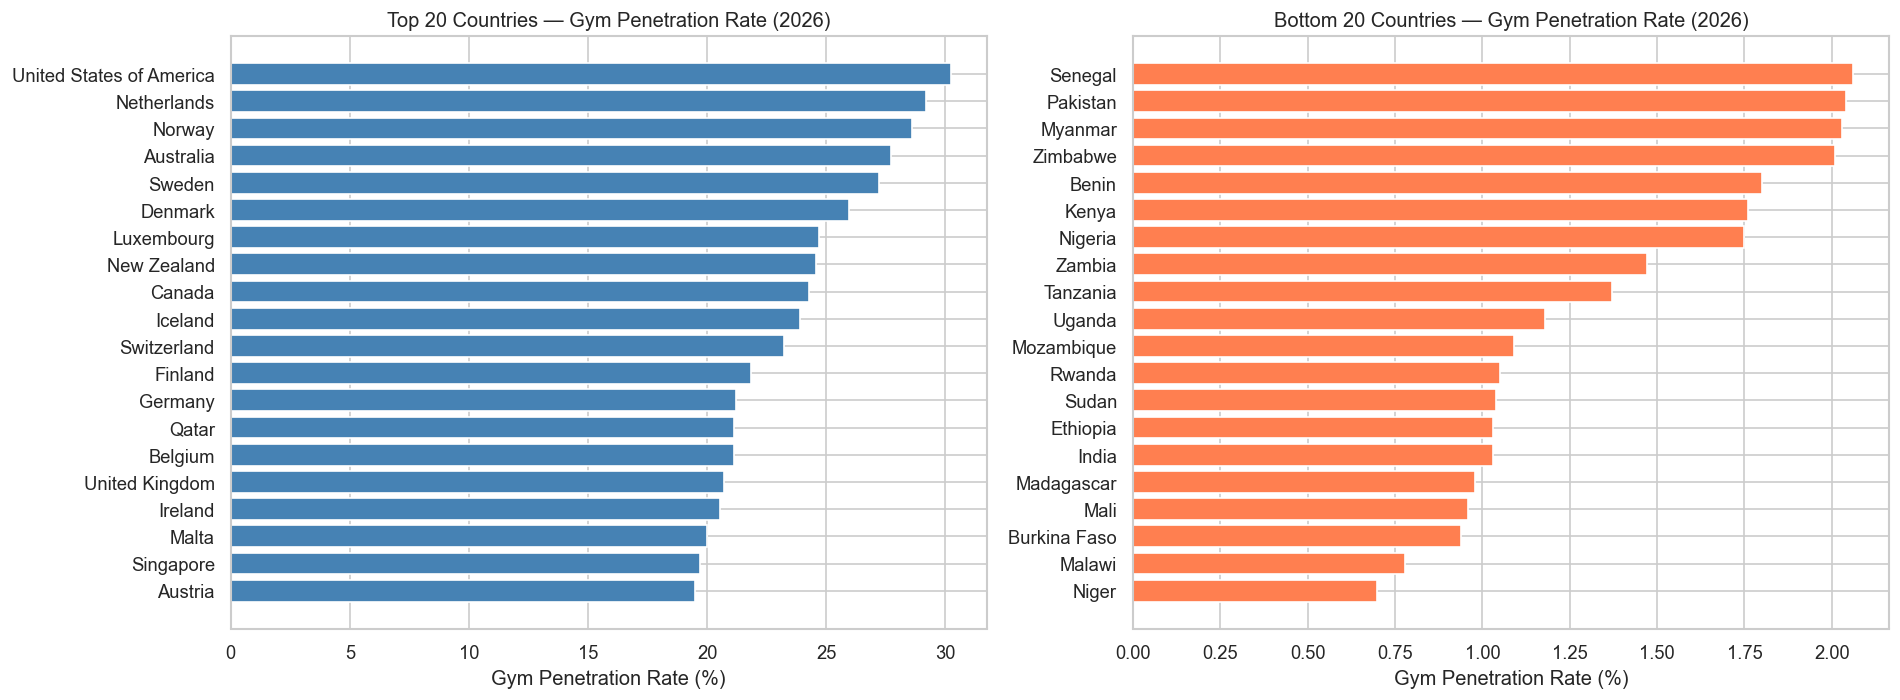

In [10]:
# Top 20 countries by gym penetration rate (latest year 2026)
df_latest = df[df['year'] == df['year'].max()].sort_values('gym_penetration_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top20 = df_latest.head(20)
ax1 = axes[0]
bars1 = ax1.barh(range(len(top20)), top20['gym_penetration_rate'].values * 100, color='steelblue')
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(top20['country'].values)
ax1.set_xlabel('Gym Penetration Rate (%)')
ax1.set_title(f'Top 20 Countries — Gym Penetration Rate ({df.year.max()})')
ax1.invert_yaxis()

bottom20 = df_latest.tail(20)
ax2 = axes[1]
bars2 = ax2.barh(range(len(bottom20)), bottom20['gym_penetration_rate'].values * 100, color='coral')
ax2.set_yticks(range(len(bottom20)))
ax2.set_yticklabels(bottom20['country'].values)
ax2.set_xlabel('Gym Penetration Rate (%)')
ax2.set_title(f'Bottom 20 Countries — Gym Penetration Rate ({df.year.max()})')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Numerical Distributions

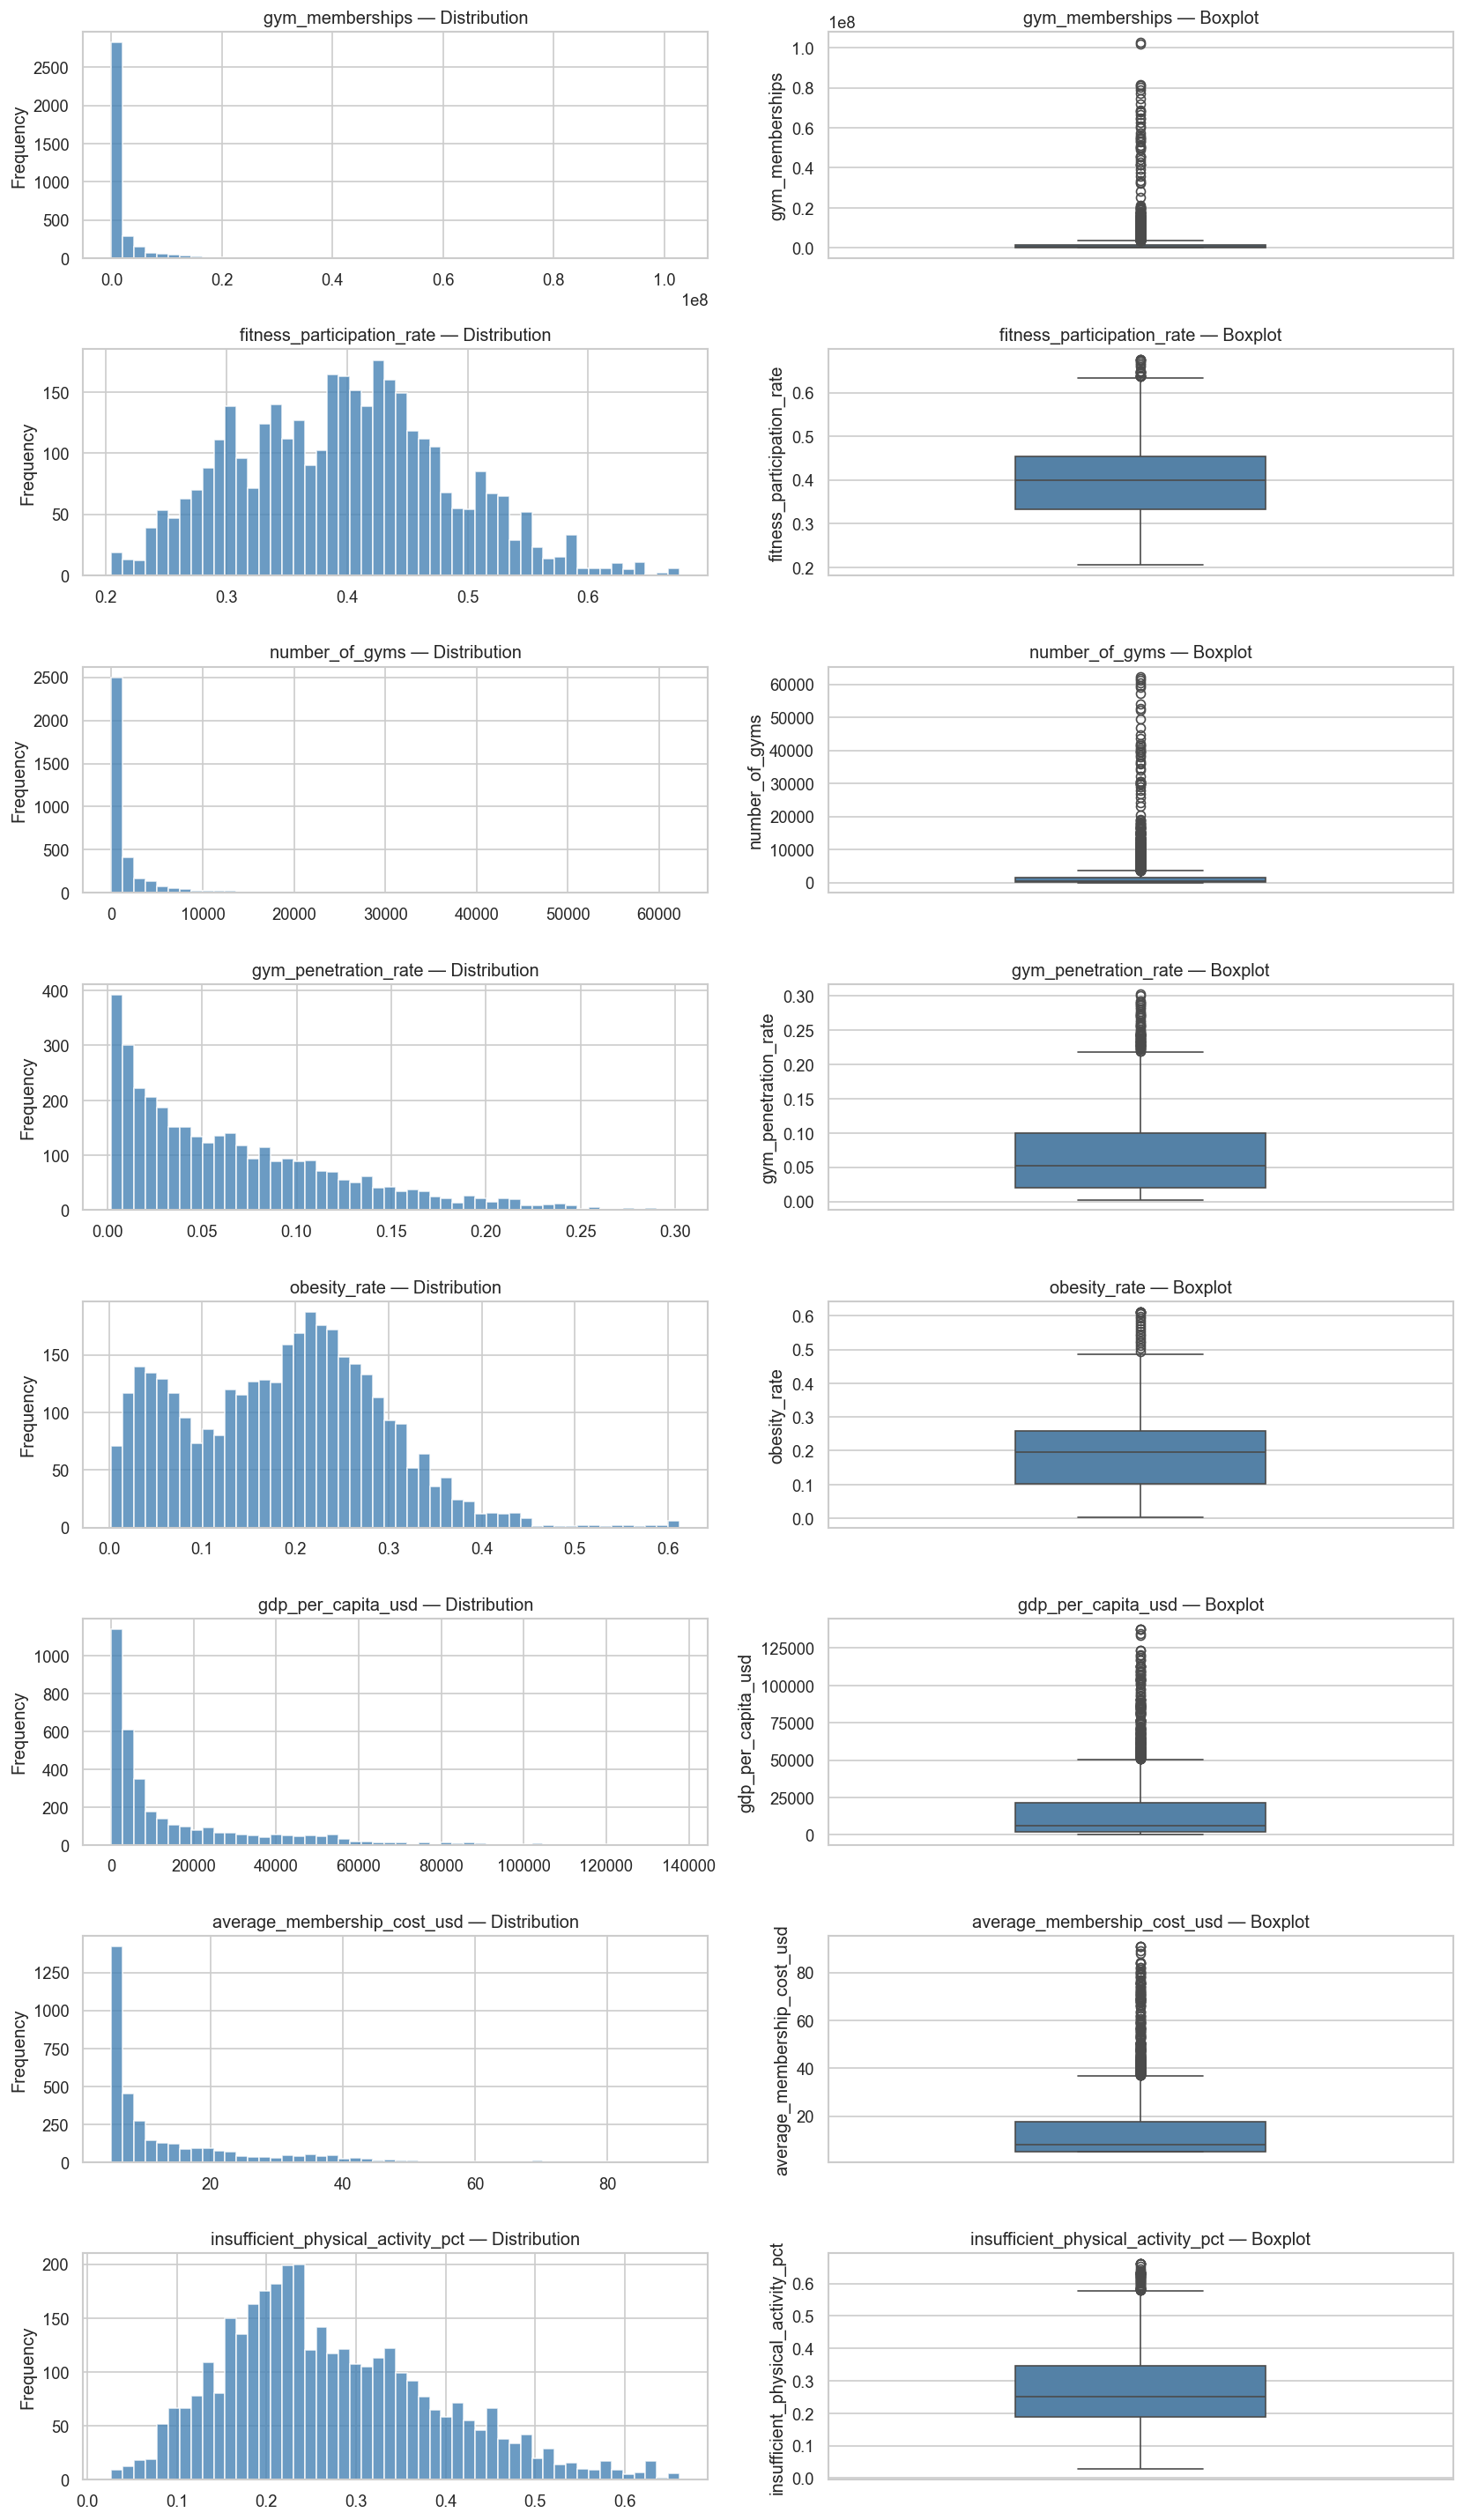

In [11]:
# Histograms + Boxplots for key numeric columns
key_num_cols = [
    'gym_memberships', 'fitness_participation_rate', 'number_of_gyms',
    'gym_penetration_rate', 'obesity_rate', 'gdp_per_capita_usd',
    'average_membership_cost_usd', 'insufficient_physical_activity_pct'
]

n = len(key_num_cols)
fig, axes = plt.subplots(n, 2, figsize=(14, n * 3))

for i, col in enumerate(key_num_cols):
    # Histogram
    ax_hist = axes[i][0]
    ax_hist.hist(df[col].dropna(), bins=50, edgecolor='white', color='steelblue', alpha=0.8)
    ax_hist.set_title(f'{col} — Distribution')
    ax_hist.set_ylabel('Frequency')
    
    # Boxplot
    ax_box = axes[i][1]
    sns.boxplot(y=df[col], ax=ax_box, color='steelblue', width=0.4)
    ax_box.set_title(f'{col} — Boxplot')

plt.tight_layout()
plt.show()

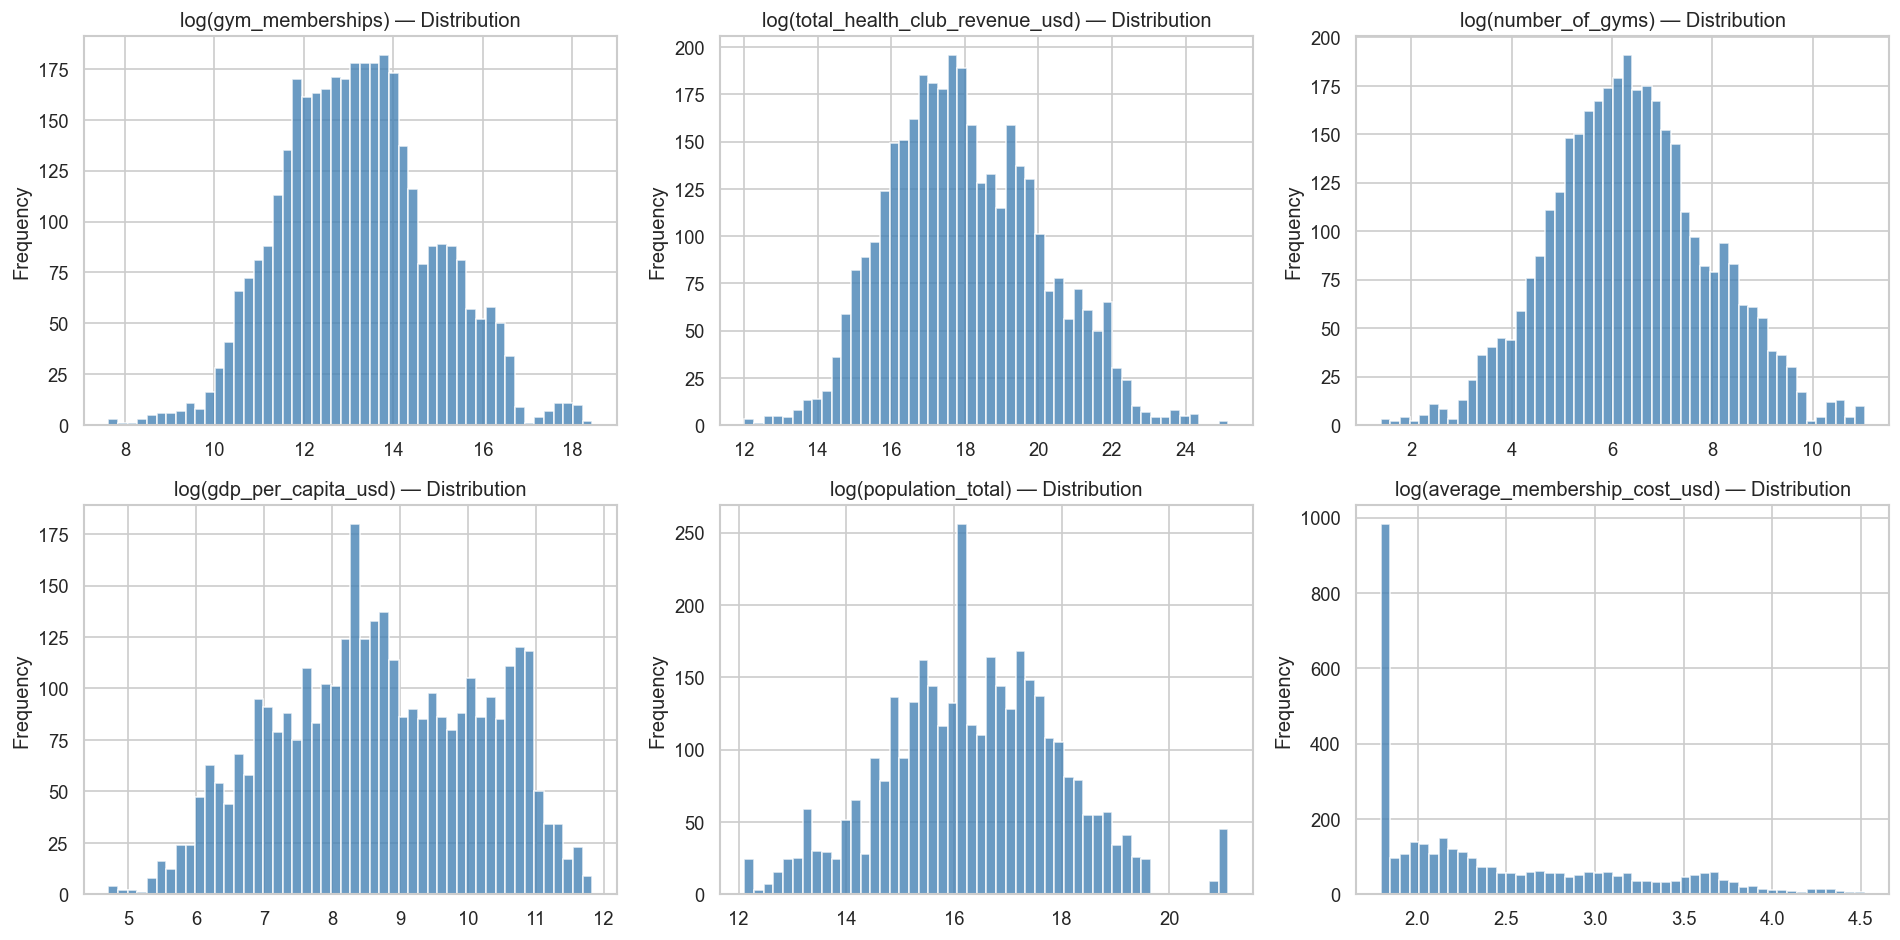

In [12]:
# Log-transform for highly skewed features
skewed_cols = ['gym_memberships', 'total_health_club_revenue_usd', 'number_of_gyms',
               'gdp_per_capita_usd', 'population_total', 'average_membership_cost_usd']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    ax = axes[i]
    ax.hist(np.log1p(df[col].dropna()), bins=50, edgecolor='white', color='steelblue', alpha=0.8)
    ax.set_title(f'log({col}) — Distribution')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 6. Time Series Trends

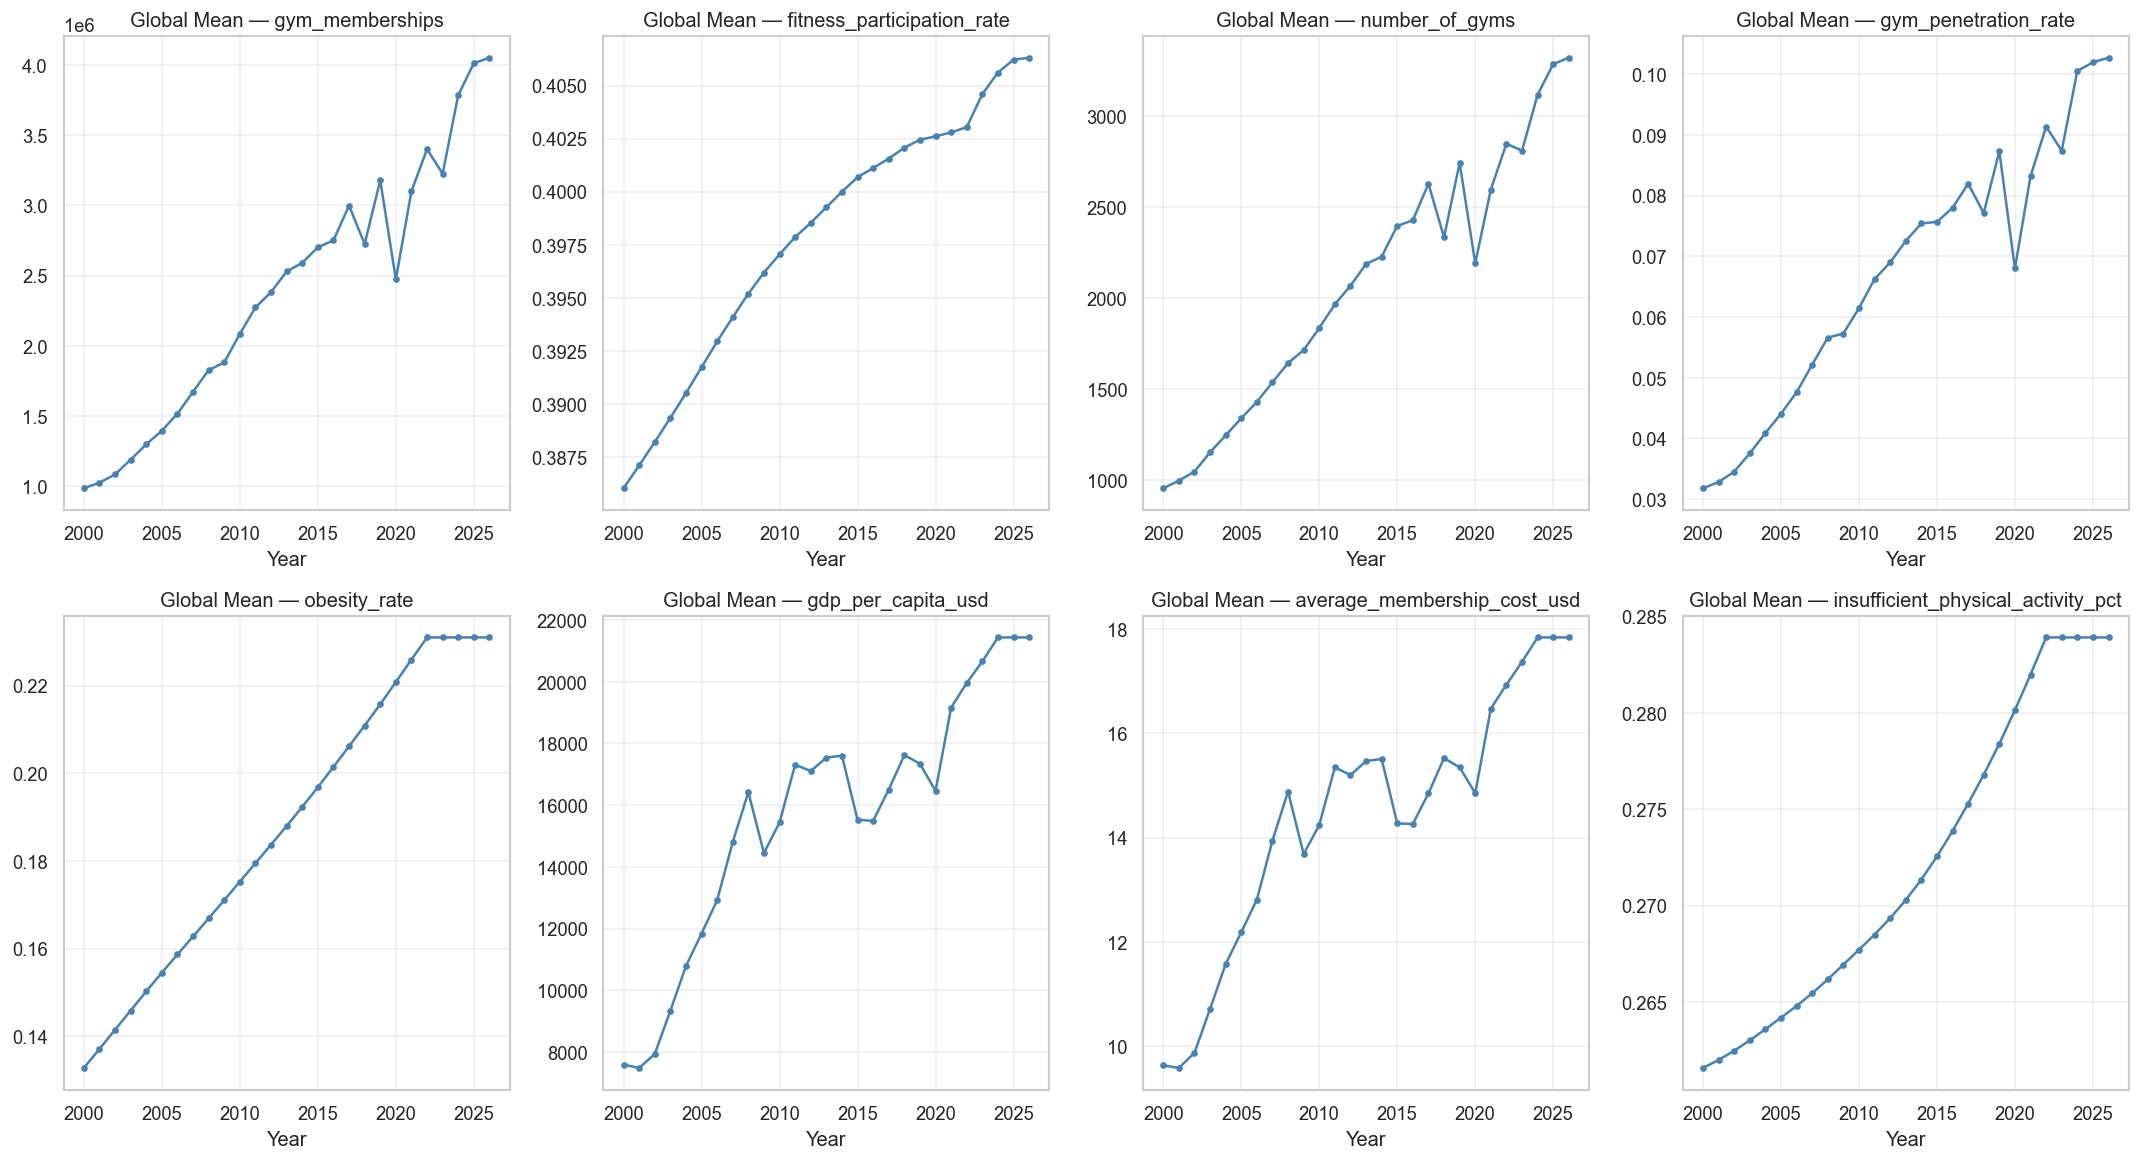

In [13]:
# Global trends over time
global_trends = df.groupby('year')[key_num_cols].mean().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    ax = axes[i]
    ax.plot(global_trends['year'], global_trends[col], marker='o', linewidth=1.5, markersize=3, color='steelblue')
    ax.set_title(f'Global Mean — {col}')
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

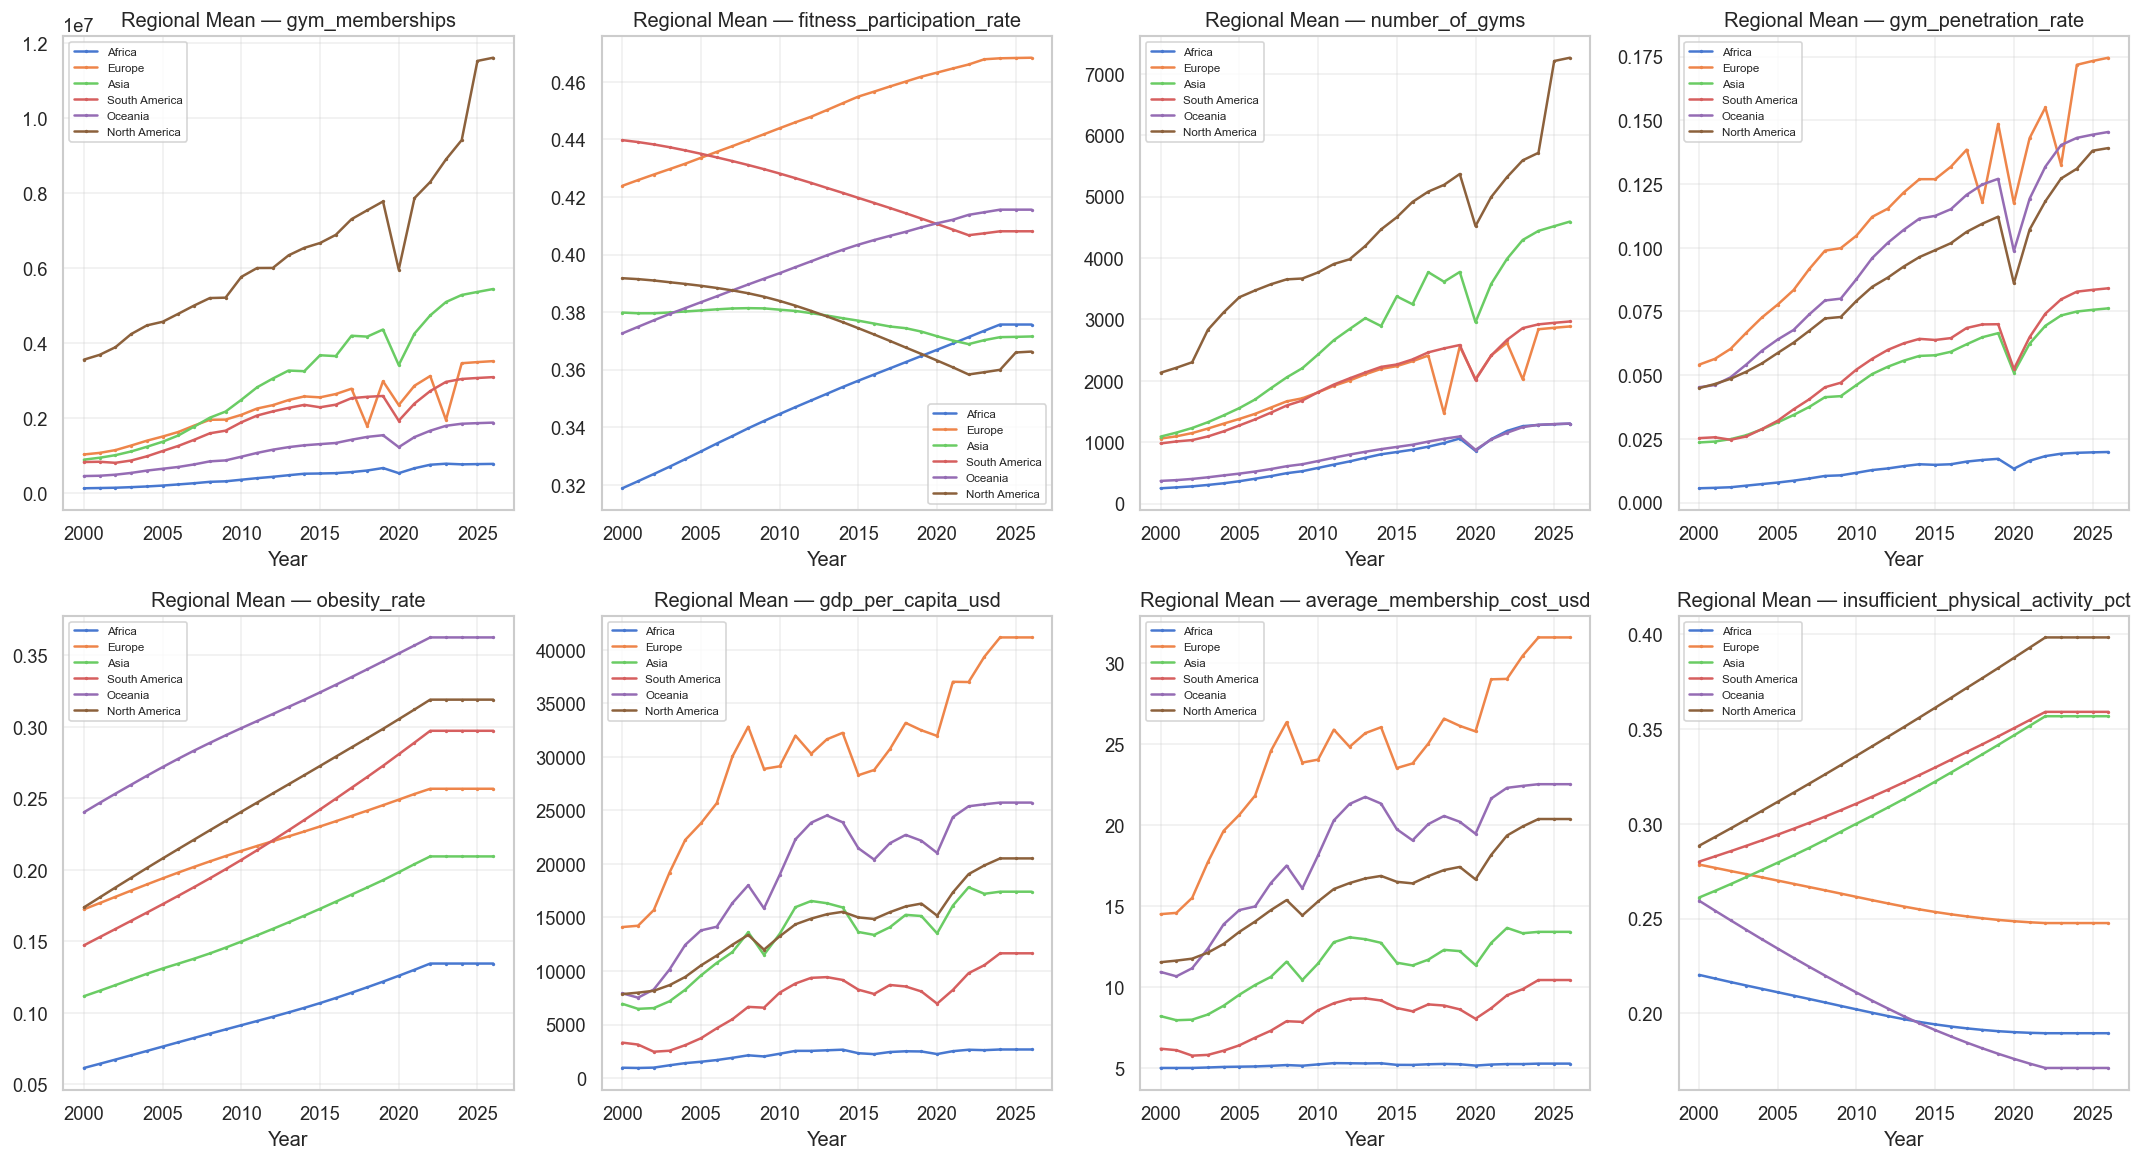

In [14]:
# Regional trends over time
region_trends = df.groupby(['year', 'region'])[key_num_cols].mean().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_cols):
    ax = axes[i]
    for region in df['region'].unique():
        subset = region_trends[region_trends['region'] == region]
        ax.plot(subset['year'], subset[col], marker='.', linewidth=1.5, markersize=2, label=region)
    ax.set_title(f'Regional Mean — {col}')
    ax.set_xlabel('Year')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

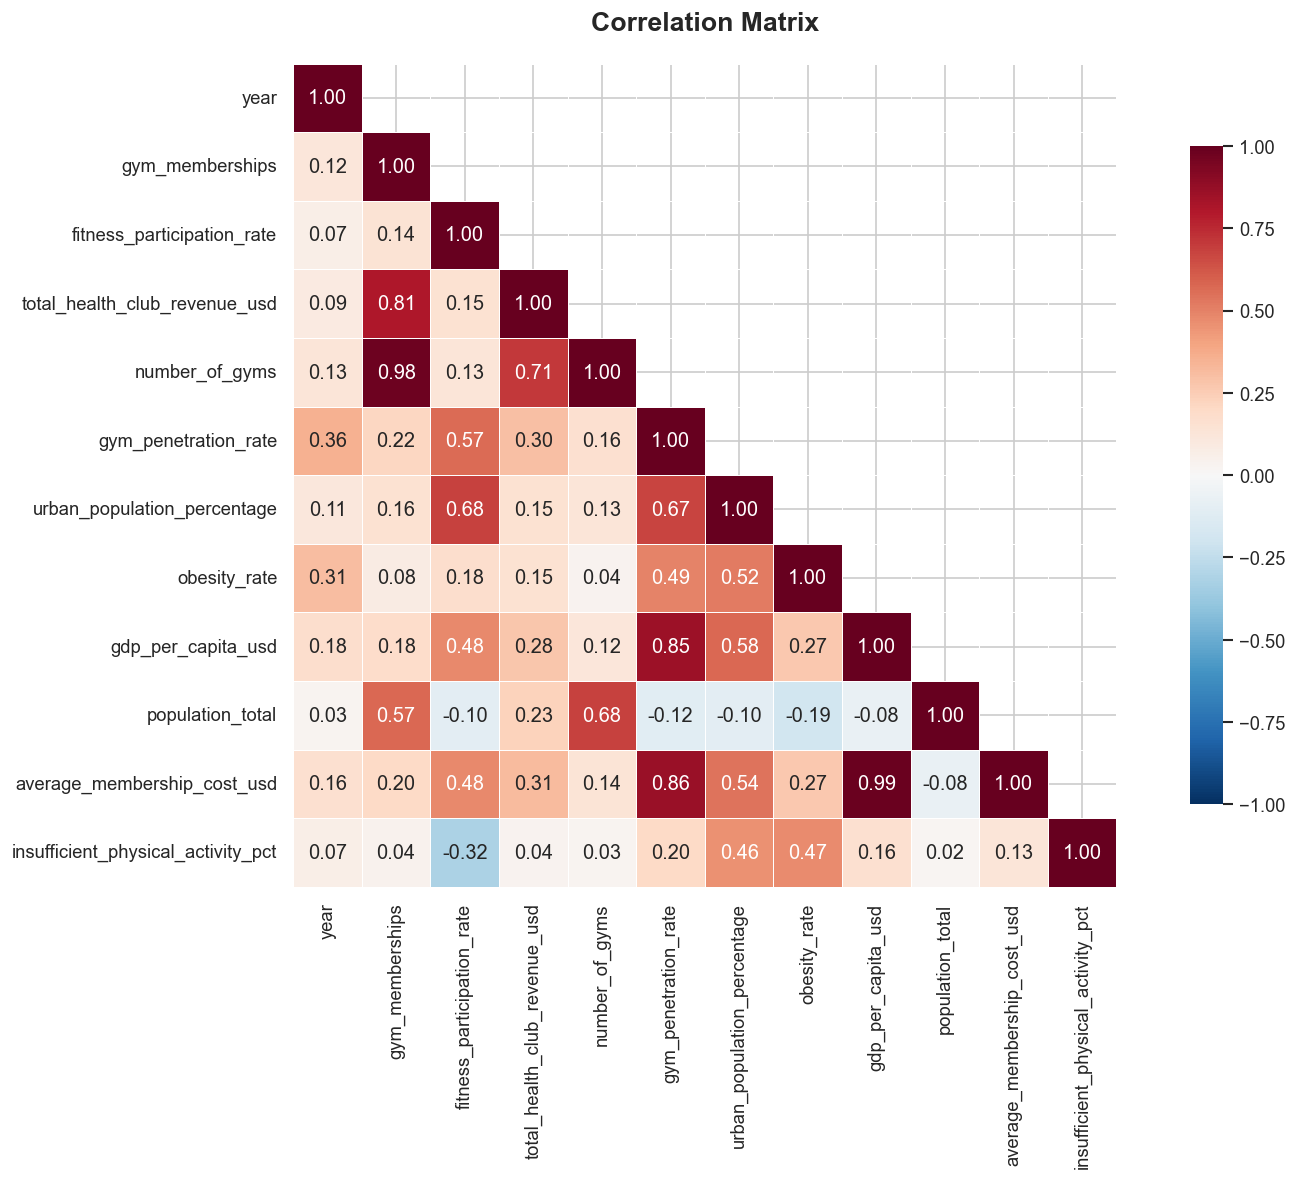

In [15]:
# Correlation matrix
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [16]:
# Top correlated pairs (excluding self-correlation and year)
corr_pairs = corr.unstack().reset_index()
corr_pairs.columns = ['var1', 'var2', 'correlation']
corr_pairs = corr_pairs[corr_pairs['var1'] != corr_pairs['var2']]
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
corr_pairs = corr_pairs.sort_values('abs_corr', ascending=False).drop_duplicates(subset=['abs_corr']).head(15)

print('Top 15 strongest correlations:')
corr_pairs[['var1', 'var2', 'correlation']]

Top 15 strongest correlations:


,var1,var2,correlation
106,gdp_per_capita_usd,average_membership_cost_usd,0.989220
49,number_of_gyms,gym_memberships,0.977419
125,average_membership_cost_usd,gym_penetration_rate,0.862586
68,gym_penetration_rate,gdp_per_capita_usd,0.854559
15,gym_memberships,total_health_club_revenue_usd,0.812254
40,total_health_club_revenue_usd,number_of_gyms,0.705429
74,urban_population_percentage,fitness_participation_rate,0.683772
57,number_of_gyms,population_total,0.681149
66,gym_penetration_rate,urban_population_percentage,0.672900
80,urban_population_percentage,gdp_per_capita_usd,0.577835


## 8. Relationships & Pairwise Insights

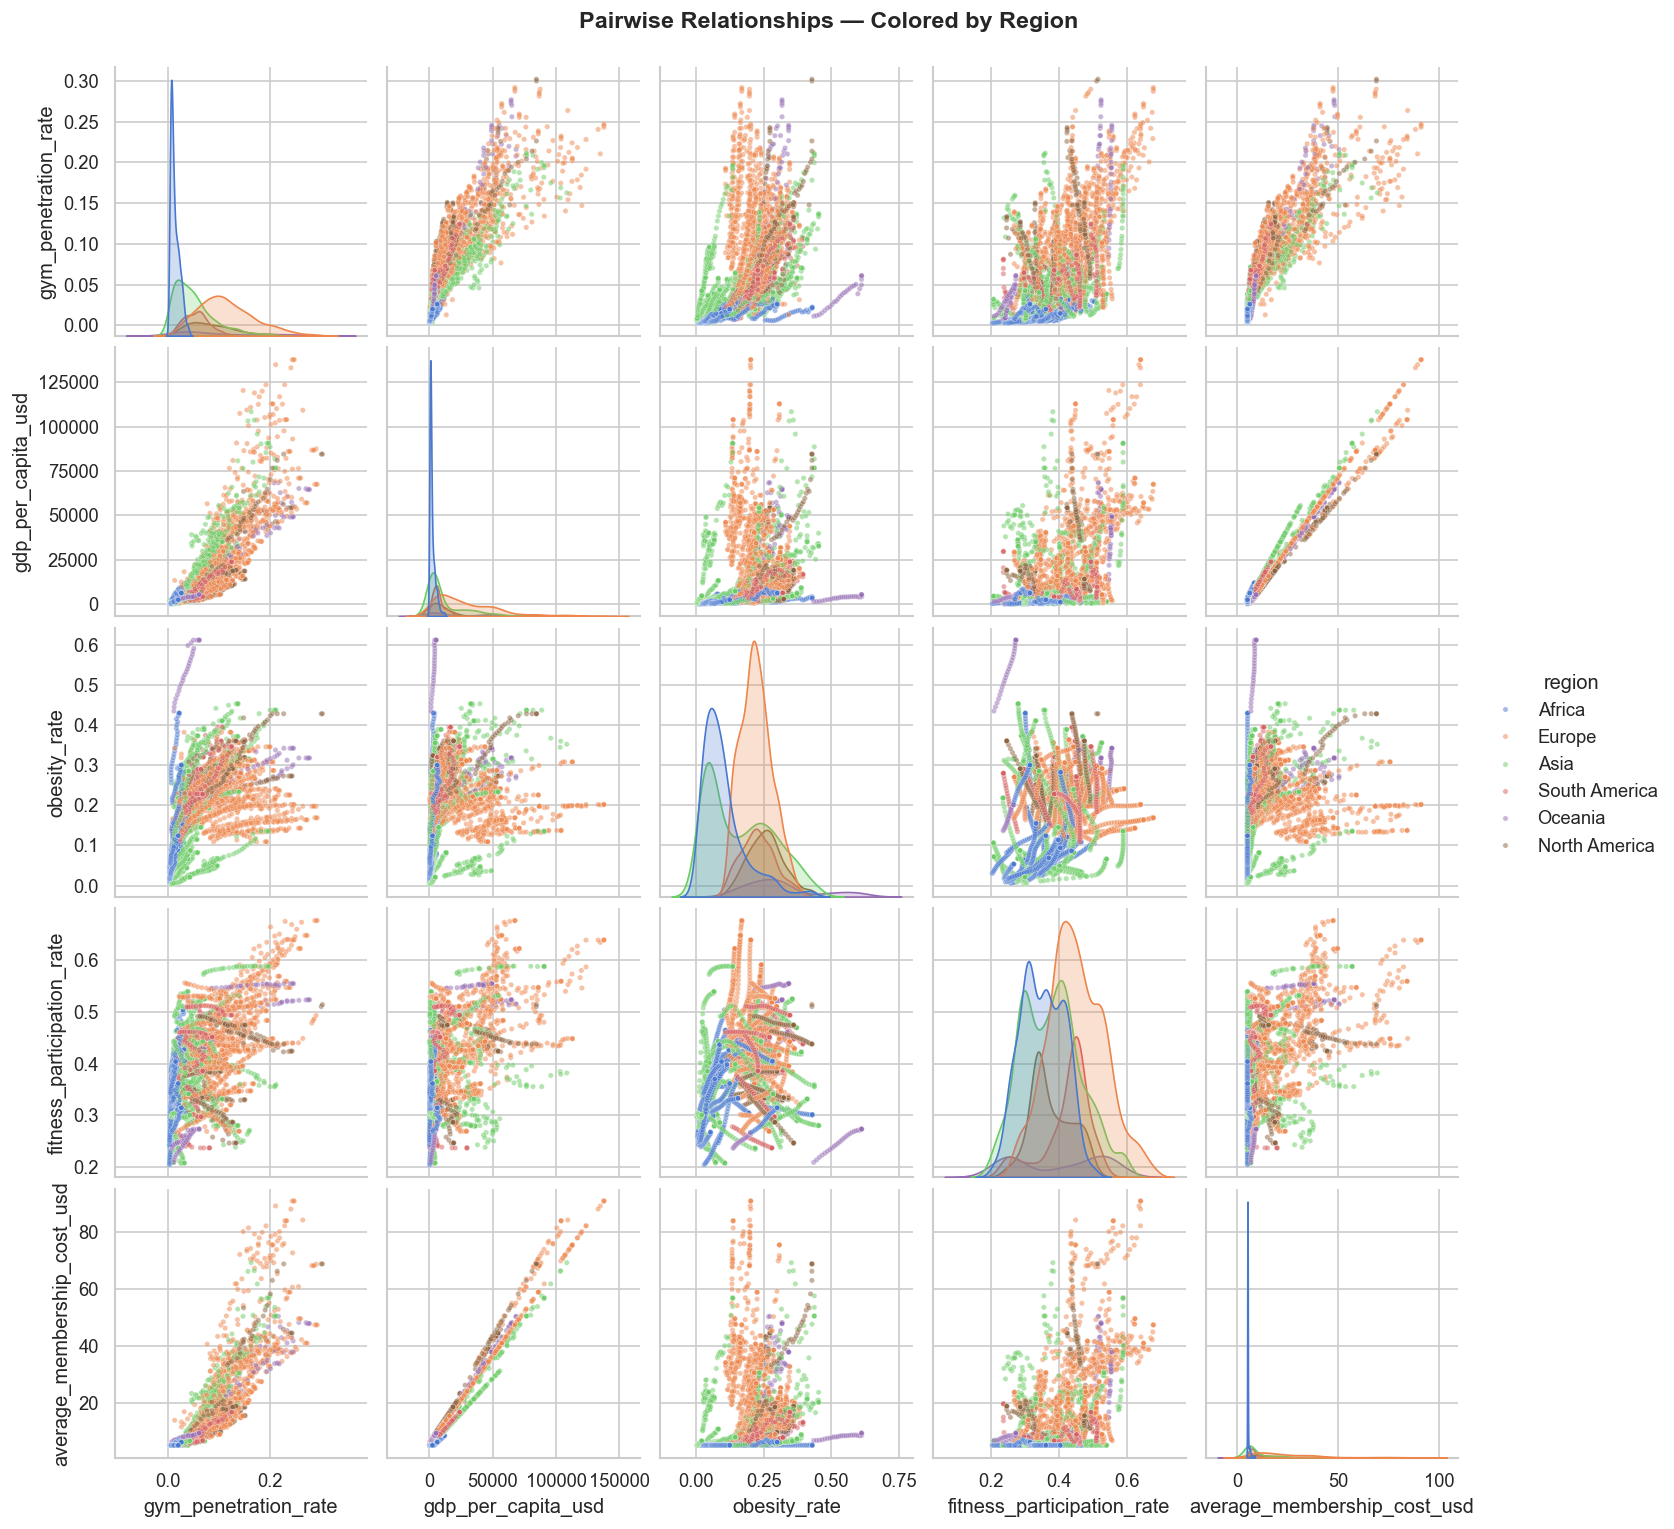

In [17]:
# Scatter matrix for key variables colored by region
scatter_cols = ['gym_penetration_rate', 'gdp_per_capita_usd',
                'obesity_rate', 'fitness_participation_rate', 'average_membership_cost_usd']

sns.pairplot(df[scatter_cols + ['region']].dropna(),
             hue='region', palette='muted', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pairwise Relationships — Colored by Region', y=1.02, fontsize=14, fontweight='bold')
plt.show()

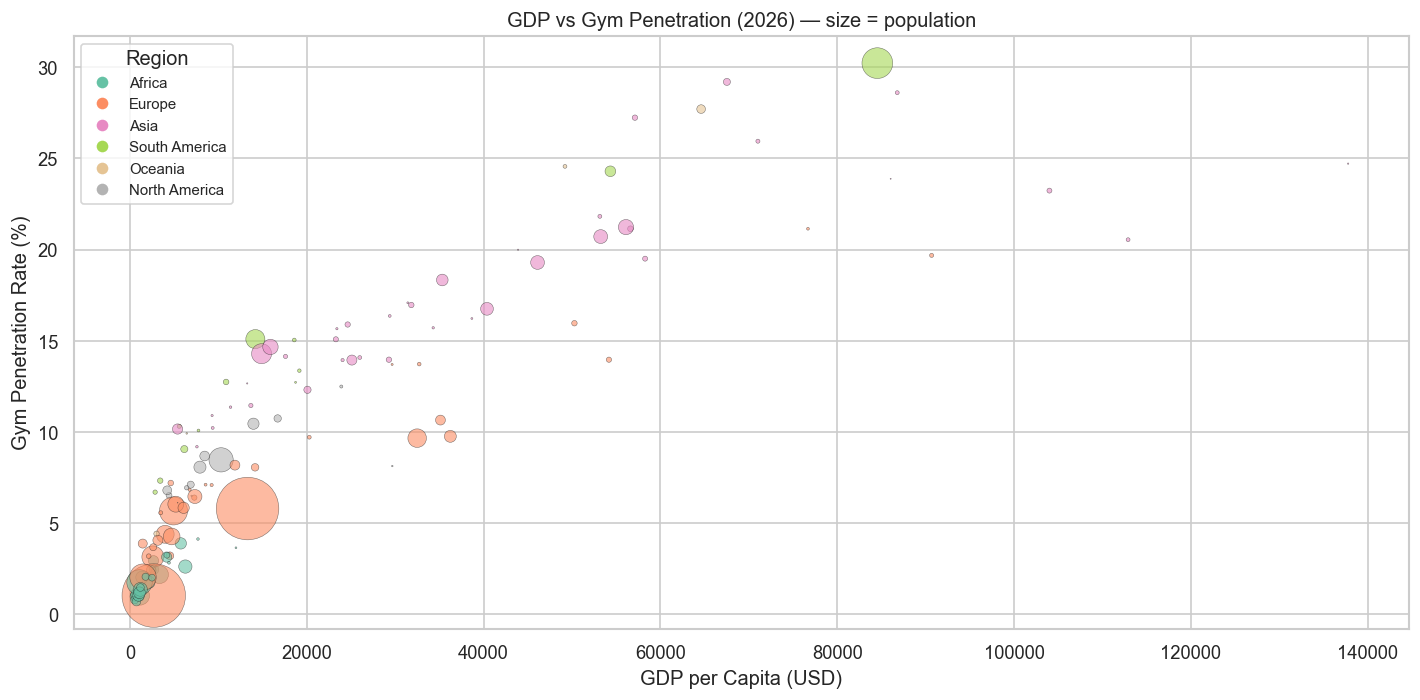

In [18]:
# GDP vs Gym Penetration by region (latest year)
df_latest = df[df['year'] == df['year'].max()].copy()

plt.figure(figsize=(12, 6))
scatter = plt.scatter(
    df_latest['gdp_per_capita_usd'], df_latest['gym_penetration_rate'] * 100,
    c=df_latest['region'].astype('category').cat.codes,
    s=df_latest['population_total'] / 1e6, alpha=0.6, cmap='Set2', edgecolors='k', linewidth=0.3
)
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Gym Penetration Rate (%)')
plt.title(f'GDP vs Gym Penetration ({df.year.max()}) — size = population')

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
                      markersize=8, label=r)
           for c, r in zip(plt.cm.Set2(np.linspace(0, 1, 6)), df['region'].unique())]
plt.legend(handles=handles, title='Region', fontsize=9)
plt.tight_layout()
plt.show()

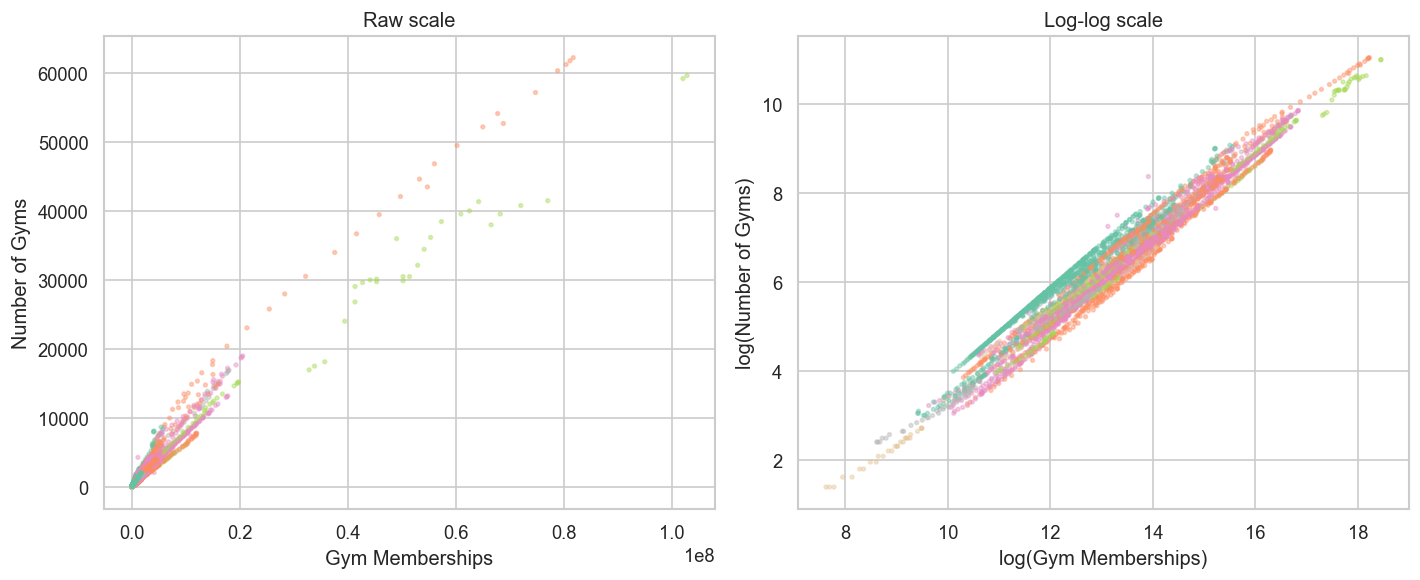

In [19]:
# Gym memberships vs number_of_gyms (log-log scatter)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['gym_memberships'], df['number_of_gyms'],
            c=df['region'].astype('category').cat.codes, alpha=0.4, s=5, cmap='Set2')
plt.xlabel('Gym Memberships')
plt.ylabel('Number of Gyms')
plt.title('Raw scale')

plt.subplot(1, 2, 2)
plt.scatter(np.log1p(df['gym_memberships']), np.log1p(df['number_of_gyms']),
            c=df['region'].astype('category').cat.codes, alpha=0.4, s=5, cmap='Set2')
plt.xlabel('log(Gym Memberships)')
plt.ylabel('log(Number of Gyms)')
plt.title('Log-log scale')

plt.tight_layout()
plt.show()

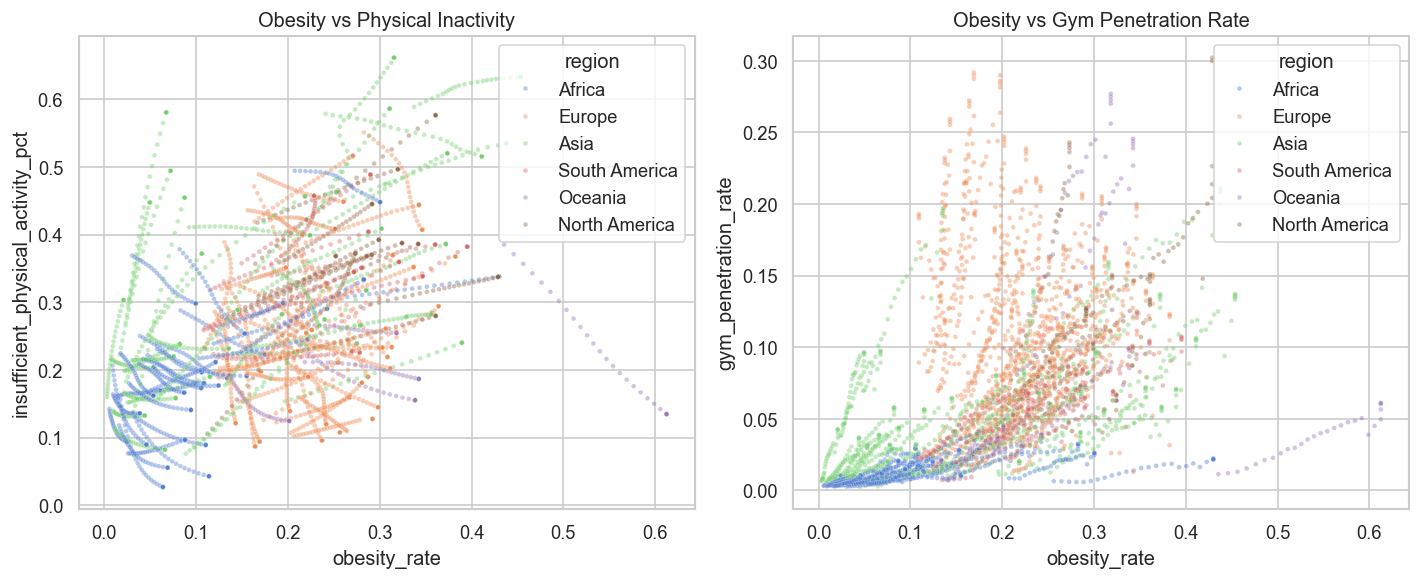

In [20]:
# Obesity rate vs insufficient physical activity
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='obesity_rate', y='insufficient_physical_activity_pct',
                hue='region', alpha=0.4, s=8, palette='muted')
plt.title('Obesity vs Physical Inactivity')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='obesity_rate', y='gym_penetration_rate',
                hue='region', alpha=0.4, s=8, palette='muted')
plt.title('Obesity vs Gym Penetration Rate')

plt.tight_layout()
plt.show()

## 9. Regional Comparison — Radar Chart

/Users/iossetking/Projects/Github/PF_P3_SGII/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/iossetking/Projects/Github/PF_P3_SGII/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/iossetking/Projects/Github/PF_P3_SGII/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/iossetking/Projects/Github/PF_P3_SGII/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/iossetking/Projects/Github/PF_P3_SGII/.venv/lib/python3.13/site-packages/sklearn/

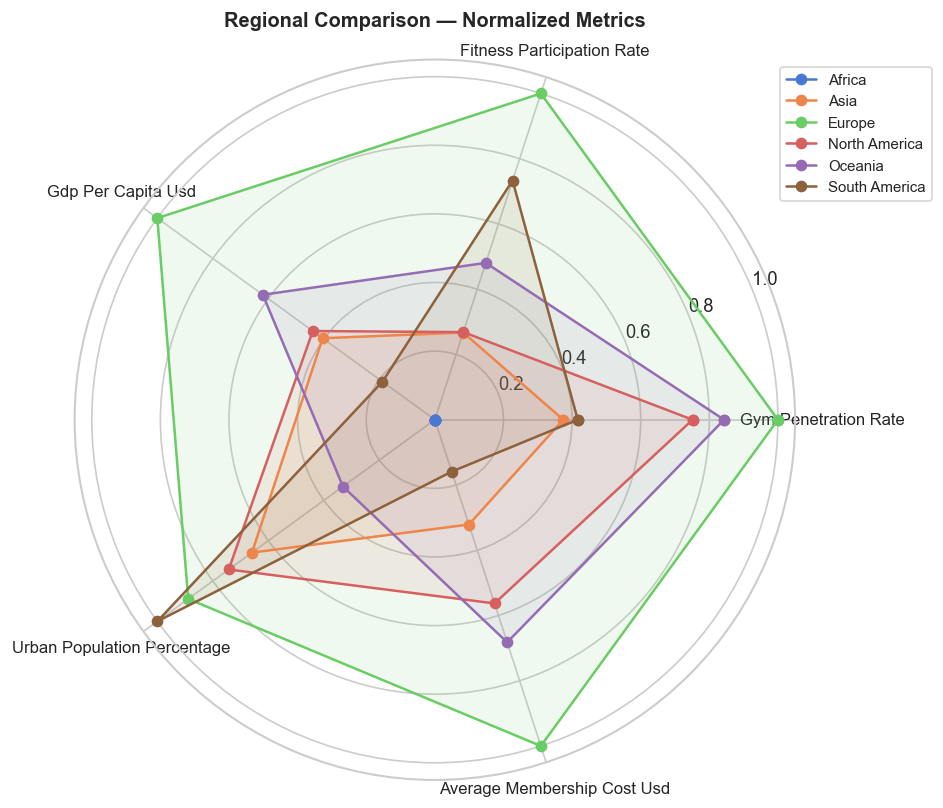

In [21]:
# Normalize metrics for radar
radar_metrics = ['gym_penetration_rate', 'fitness_participation_rate',
                 'gdp_per_capita_usd', 'urban_population_percentage',
                 'average_membership_cost_usd']

region_avg = df.groupby('region')[radar_metrics].mean().reset_index()

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled = scaler.fit_transform(region_avg[radar_metrics])

categories = [m.replace('_', ' ').title() for m in radar_metrics]
n_cats = len(categories)
angles = [n / float(n_cats) * 2 * pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

colors = sns.color_palette('muted', len(region_avg))
for idx, row in region_avg.iterrows():
    values = scaler.transform([row[radar_metrics]])[0].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=1.5, label=row['region'], color=colors[idx])
    ax.fill(angles, values, alpha=0.1, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0), fontsize=9)
ax.set_title('Regional Comparison — Normalized Metrics', pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Outlier Detection

In [22]:
# IQR-based outlier count per numeric column
outlier_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_outliers = n_outliers / len(df) * 100
    outlier_summary.append({'column': col, 'lower_bound': lower, 'upper_bound': upper,
                           'n_outliers': n_outliers, 'percent': f'{pct_outliers:.1f}%'})

outlier_df = pd.DataFrame(outlier_summary).sort_values('n_outliers', ascending=False)
outlier_df

,column,lower_bound,upper_bound,n_outliers,percent
1,gym_memberships,-1.933826e+06,3.657316e+06,522,14.6%
3,total_health_club_revenue_usd,-3.723179e+08,6.614133e+08,514,14.4%
4,number_of_gyms,-1.858625e+03,3.644375e+03,493,13.8%
9,population_total,-4.587889e+07,8.837709e+07,374,10.5%
10,average_membership_cost_usd,-1.403875e+01,3.689125e+01,298,8.4%
8,gdp_per_capita_usd,-2.715579e+04,5.062247e+04,287,8.1%
5,gym_penetration_rate,-1.002500e-01,2.193500e-01,72,2.0%
11,insufficient_physical_activity_pct,-4.753750e-02,5.805625e-01,52,1.5%
2,fitness_participation_rate,1.521250e-01,6.347250e-01,21,0.6%
7,obesity_rate,-1.316625e-01,4.940375e-01,21,0.6%


In [23]:
# Z-score based outliers (threshold = 3)
from scipy import stats

z_outliers = []
for col in num_cols:
    z = np.abs(stats.zscore(df[col].dropna()))
    n_out = (z > 3).sum()
    z_outliers.append({'column': col, 'n_zscore_outliers': n_out,
                      'percent': f'{n_out / len(df) * 100:.1f}%'})

z_outlier_df = pd.DataFrame(z_outliers).sort_values('n_zscore_outliers', ascending=False)
z_outlier_df

,column,n_zscore_outliers,percent
10,average_membership_cost_usd,85,2.4%
8,gdp_per_capita_usd,83,2.3%
9,population_total,54,1.5%
4,number_of_gyms,50,1.4%
1,gym_memberships,46,1.3%
5,gym_penetration_rate,39,1.1%
3,total_health_club_revenue_usd,31,0.9%
11,insufficient_physical_activity_pct,21,0.6%
7,obesity_rate,20,0.6%
2,fitness_participation_rate,7,0.2%


## 11. Key Findings & Summary

In [24]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)

summary = (
    f'  Dataset       : {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns\n'
    f'  Time span     : {df.year.min()} \u2013 {df.year.max()}\n'
    f'  Countries     : {df.country.nunique()}\n'
    f'  Regions       : {df.region.nunique()} \u2192 {', '.join(sorted(df["region"].unique()))}\n'
    f'  Missing vals  : {df.isnull().sum().sum()}\n'
    f'  Duplicates    : {df.duplicated().sum()}\n'
)
print(summary)

print('  Most correlated pair:')
top_pair = corr_pairs.iloc[0]
print(f'    {top_pair["var1"]} \u2194 {top_pair["var2"]}: r = {top_pair["correlation"]:.3f}')

print('\n  Region with highest avg gym penetration:')
best_region = df.groupby('region')['gym_penetration_rate'].mean().idxmax()
print(f'    {best_region}')

print('  Region with highest avg obesity rate:')
fattest_region = df.groupby('region')['obesity_rate'].mean().idxmax()
print(f'    {fattest_region}')

print(f'  Country with highest gym penetration ({df.year.max()}):')
top_country = df_latest.loc[df_latest['gym_penetration_rate'].idxmax(), 'country']
print(f'    {top_country}')

print('=' * 60)

EDA SUMMARY
  Dataset       : 3,564 rows × 14 columns
  Time span     : 2000 – 2026
  Countries     : 132
  Regions       : 6 → Africa, Asia, Europe, North America, Oceania, South America
  Missing vals  : 0
  Duplicates    : 0

  Most correlated pair:
    gdp_per_capita_usd ↔ average_membership_cost_usd: r = 0.989

  Region with highest avg gym penetration:
    Europe
  Region with highest avg obesity rate:
    Oceania
  Country with highest gym penetration (2026):
    United States of America
